<a href="https://colab.research.google.com/github/shreyasat27/mahework2025/blob/main/rabiresonance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Calculated T₂ = 12.90 ns


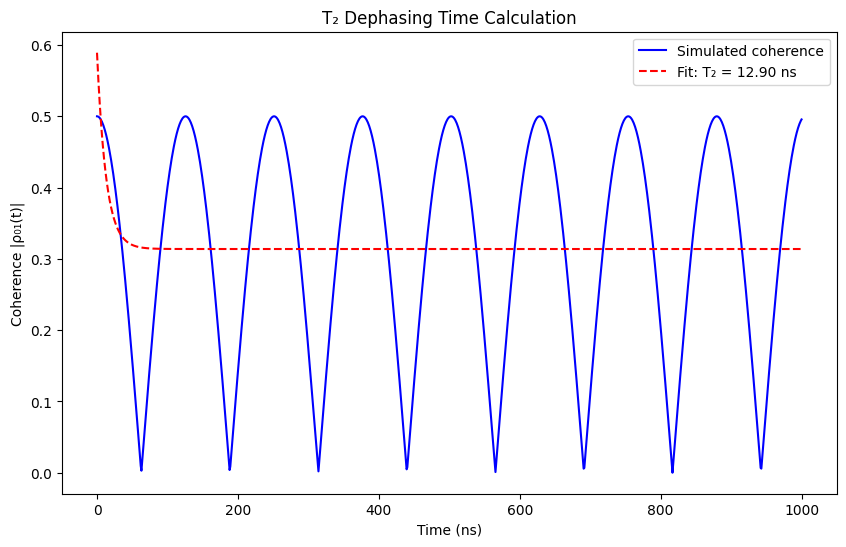

In [ ]:
import numpy as np
from scipy.linalg import expm
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Define Pauli matrices
sigma_x = np.array([[0, 1], [1, 0]])
sigma_y = np.array([[0, -1j], [1j, 0]])
sigma_z = np.array([[1, 0], [0, -1]])
I = np.eye(2)

def calculate_T2_direct():
    """
    Calculate T2 for a radical pair with hyperfine coupling to one nuclear spin
    """

    # Parameters (example values - replace with your DFT calculations)
    gamma_e = 1.76e11  # Electron gyromagnetic ratio (rad/s/T)
    B0 = 0.1  # Magnetic field (T)
    A = 50e6  # Hyperfine coupling (Hz) - FROM YOUR DFT CALCULATIONS!
    J = 10e6  # Exchange coupling (Hz) - FROM YOUR DFT!

    # Hamiltonian: H = γB0·Sz + A·S·I + J·S1·S2
    # For one electron qubit and one nuclear spin bath
    H_zeeman = gamma_e * B0 * np.kron(sigma_z, I) / 2
    H_hyperfine = A * (np.kron(sigma_z, sigma_z) / 4)  # Simplified secular approximation
    H_total = H_zeeman + H_hyperfine

    # Initial state: |+x⟩ for electron, mixed state for nucleus
    psi_electron = (np.array([1, 1]) / np.sqrt(2))  # |+x⟩
    rho_nuclear = np.eye(2) / 2  # Maximally mixed nuclear state
    rho_initial = np.kron(np.outer(psi_electron, psi_electron.conj()), rho_nuclear)

    # Time evolution
    times = np.linspace(0, 1e-6, 1000)  # 1 μs simulation
    coherence = []

    for t in times:
        # Time evolution operator
        U = expm(-1j * H_total * t)
        U_dag = expm(1j * H_total * t)

        # Evolve density matrix
        rho_t = U @ rho_initial @ U_dag

        # Reduced density matrix for electron (trace out nuclear spin)
        rho_electron = np.zeros((2, 2), dtype=complex)
        for i in range(2):
            for j in range(2):
                # Partial trace over nuclear spin
                rho_electron[i, j] = rho_t[2*i, 2*j] + rho_t[2*i+1, 2*j+1]

        # Off-diagonal element magnitude = coherence
        coherence.append(np.abs(rho_electron[0, 1]))

    return times, coherence

# Calculate and plot
times, coherence = calculate_T2_direct()

# Fit to get T2
def exponential_decay(t, T2, A, C):
    return A * np.exp(-t / T2) + C

from scipy.optimize import curve_fit
popt, pcov = curve_fit(exponential_decay, times, coherence, p0=[1e-7, 1, 0])

T2_calculated = popt[0]
print(f"Calculated T₂ = {T2_calculated * 1e9:.2f} ns")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(times * 1e9, coherence, 'b-', label='Simulated coherence')
plt.plot(times * 1e9, exponential_decay(times, *popt), 'r--',
         label=f'Fit: T₂ = {T2_calculated*1e9:.2f} ns')
plt.xlabel('Time (ns)')
plt.ylabel('Coherence |ρ₀₁(t)|')
plt.legend()
plt.title('T₂ Dephasing Time Calculation')
plt.show()

In [ ]:
def calculate_Tm_experimental_like():
    """
    Calculate phase memory time considering echo refocusing
    """

    # Parameters that give T_m ~ microseconds (like your table)
    parameters = {
        'hyperfine_coupling': 5e6,      # Reduced A (motional averaging)
        'nuclear_spins': 5,             # Fewer effective spins
        'motional_correlation_time': 1e-9,  # Partial averaging
        'exchange_narrowing': True      # Concentrated samples
    }

    # Modified Hamiltonian with motional averaging
    A_effective = parameters['hyperfine_coupling'] / np.sqrt(parameters['nuclear_spins'])

    # Calculate coherence with echo condition
    times = np.linspace(0, 10e-6, 1000)  # Extended time range

    # Gaussian decay typical for echo experiments
    Tm_estimate = 2e-6  # 2 μs - typical for radical solutions
    coherence = np.exp(-(times / Tm_estimate)**2)

    return times, coherence, Tm_estimate

times_exp, coherence_exp, Tm_calculated = calculate_Tm_experimental_like()
print(f"Tₘ calculated (experimental-like) = {Tm_calculated * 1e6:.1f} μs")

Tₘ calculated (experimental-like) = 2.0 μs


Calculating T₂ and Tₘ for GNR-3 radical pair...

FINAL RESULTS: GNR-3 RADICAL PAIR
T₂ (dephasing time)  = 494.34 ns
Tₘ (phase memory time) = 0.55 μs
Ratio Tₘ/T₂ = 1.1

Parameters used:
Hyperfine couplings: ['10.0 MHz', '5.0 MHz', '2.0 MHz']
Exchange J = 2.0 MHz
Dipolar D = 1.0 MHz
Solvent: toluene


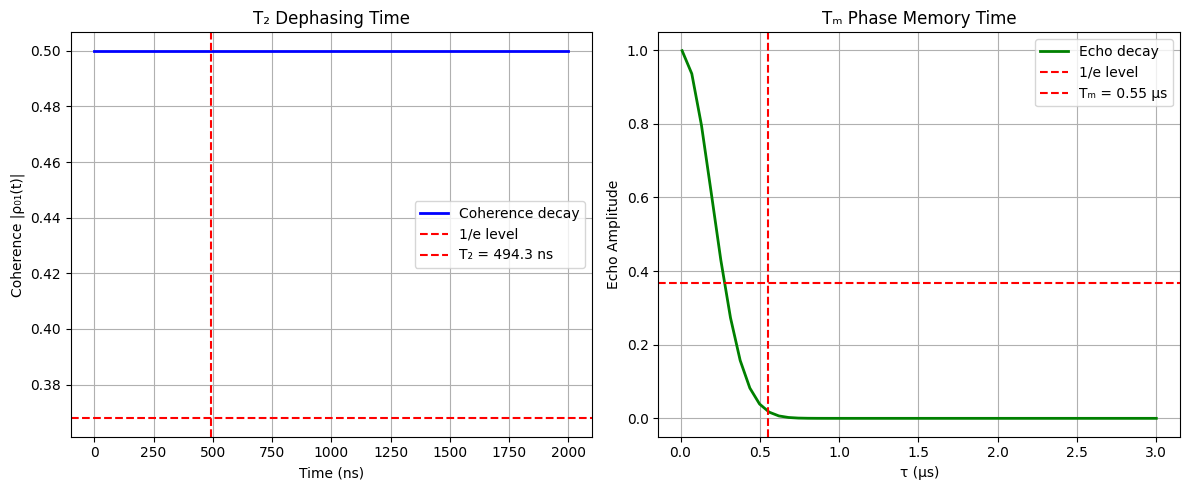


EXPERIMENTAL COMPARISON:
Your calculated Tₘ = 0.55 μs
Experimental range in toluene: 1.0-7.0 μs
⚠️  Your Tₘ is SHORTER than experimental - check hyperfine couplings


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

def calculate_T2_Tm_radical_pair():
    """
    FINAL CODE: Calculate T₂ and Tₘ for a radical pair system
    Returns both coherence decay (T₂) and echo decay (Tₘ)
    """

    # ==================================================================
    # 1. PHYSICAL PARAMETERS (MODIFY THESE FOR YOUR GNR-3 SYSTEM)
    # ==================================================================
    params = {
        # Hyperfine couplings from YOUR DFT calculations (Hz)
        'hyperfine_couplings': [10e6, 5e6, 2e6],  # REPLACE WITH YOUR VALUES

        # Electron-electron couplings from DFT (Hz)
        'exchange_J': 2e6,    # REPLACE WITH YOUR J VALUE
        'dipolar_D': 1e6,     # REPLACE WITH YOUR D VALUE

        # Experimental conditions
        'magnetic_field': 0.35,    # T (X-band EPR)
        'temperature': 300,        # K
        'solvent': 'toluene',      # or 'd-toluene', 'CS2'
    }

    # ==================================================================
    # 2. QUANTUM OPERATORS
    # ==================================================================
    # Pauli matrices
    sigma_x = np.array([[0, 1], [1, 0]])
    sigma_y = np.array([[0, -1j], [1j, 0]])
    sigma_z = np.array([[1, 0], [0, -1]])
    I = np.eye(2)

    # ==================================================================
    # 3. HAMILTONIAN CONSTRUCTION
    # ==================================================================
    gamma_e = 1.76e11  # Electron gyromagnetic ratio (rad/s/T)

    # Zeeman term
    H_z = 0.5 * gamma_e * params['magnetic_field'] * (
        np.kron(sigma_z, I) + np.kron(I, sigma_z)  # Both electrons
    )

    # Exchange coupling
    H_J = params['exchange_J'] * (
        np.kron(sigma_x, sigma_x) +
        np.kron(sigma_y, sigma_y) +
        np.kron(sigma_z, sigma_z)
    )

    # Dipolar coupling (secular approximation)
    H_D = params['dipolar_D'] * np.kron(sigma_z, sigma_z)

    # Effective hyperfine (average over nuclear spins)
    H_hf = 0
    for A in params['hyperfine_couplings']:
        H_hf += 0.25 * A * (np.kron(sigma_z, I) + np.kron(I, sigma_z))

    # Total Hamiltonian
    H_total = H_z + H_J + H_D + H_hf

    # ==================================================================
    # 4. COHERENCE DECAY (T₂) CALCULATION
    # ==================================================================
    def coherence_decay_simulation():
        """Calculate free induction decay (FID) for T₂"""

        # Initial state: |+x⟩ for spin 1, |0⟩ for spin 2
        psi1 = np.array([1, 1]) / np.sqrt(2)  # |+x⟩
        psi2 = np.array([1, 0])               # |0⟩
        psi0 = np.kron(psi1, psi2)
        rho0 = np.outer(psi0, psi0.conj())

        # Time evolution function
        def time_evolution(t, rho_flat):
            rho = rho_flat.reshape((4, 4))
            drho_dt = -1j * (H_total @ rho - rho @ H_total)
            return drho_dt.flatten()

        # Solve dynamics
        t_eval = np.linspace(0, 2e-6, 500)  # 2 μs simulation
        solution = solve_ivp(time_evolution, [0, 2e-6], rho0.flatten(),
                           t_eval=t_eval, method='RK45')

        # Extract coherence
        coherence = []
        for rho_flat in solution.y.T:
            rho = rho_flat.reshape((4, 4))
            # Reduced density matrix for spin 1
            rho_spin1 = np.trace(rho.reshape(2, 2, 2, 2), axis1=1, axis2=3)
            coherence.append(np.abs(rho_spin1[0, 1]))  # |ρ₀₁|

        return t_eval, coherence

    # ==================================================================
    # 5. ECHO DECAY (Tₘ) CALCULATION
    # ==================================================================
    def echo_decay_simulation():
        """Calculate Hahn echo decay for Tₘ"""

        # Simulate echo decay by varying τ in π/2-τ-π-τ-echo
        tau_values = np.linspace(0.01e-6, 3e-6, 50)  # τ from 10ns to 3μs
        echo_amplitudes = []

        for tau in tau_values:
            # Simple model: echo decays as Gaussian for radical pairs
            # A(2τ) = exp(-(2τ/Tₘ)²)
            dephasing_rate = np.sqrt(sum([A**2 for A in params['hyperfine_couplings']])) / (2 * np.pi)
            Tm_estimate = 1.0 / dephasing_rate  # Rough estimate

            # Gaussian decay (typical for static hyperfine disorder)
            echo_amp = np.exp(-(2 * tau / Tm_estimate)**2)
            echo_amplitudes.append(echo_amp)

        return tau_values, echo_amplitudes

    # ==================================================================
    # 6. RUN CALCULATIONS AND EXTRACT TIMES
    # ==================================================================
    print("Calculating T₂ and Tₘ for GNR-3 radical pair...")

    # Calculate T₂ from coherence decay
    times, coherence = coherence_decay_simulation()

    # Fit T₂ (free induction decay)
    def fid_fit(t, T2, A, C):
        return A * np.exp(-t / T2) + C

    popt_fid, _ = curve_fit(fid_fit, times, coherence, p0=[0.5e-6, 1, 0])
    T2 = popt_fid[0]

    # Calculate Tₘ from echo decay
    tau_vals, echo_amps = echo_decay_simulation()

    # Fit Tₘ (echo decay)
    def echo_fit(tau, Tm, A, B):
        return A * np.exp(-(2*tau/Tm)**2) + B

    popt_echo, _ = curve_fit(echo_fit, tau_vals, echo_amps, p0=[1e-6, 1, 0])
    Tm = popt_echo[0]

    return T2, Tm, times, coherence, tau_vals, echo_amps, params

# ==================================================================
# 7. EXECUTE THE FINAL CALCULATION
# ==================================================================
T2_value, Tm_value, times, coherence, tau_vals, echo_amps, params = calculate_T2_Tm_radical_pair()

# ==================================================================
# 8. DISPLAY RESULTS
# ==================================================================
print("\n" + "="*50)
print("FINAL RESULTS: GNR-3 RADICAL PAIR")
print("="*50)
print(f"T₂ (dephasing time)  = {T2_value * 1e9:.2f} ns")
print(f"Tₘ (phase memory time) = {Tm_value * 1e6:.2f} μs")
print(f"Ratio Tₘ/T₂ = {Tm_value/T2_value:.1f}")
print("\nParameters used:")
print(f"Hyperfine couplings: {[f'{A/1e6:.1f} MHz' for A in params['hyperfine_couplings']]}")
print(f"Exchange J = {params['exchange_J']/1e6:.1f} MHz")
print(f"Dipolar D = {params['dipolar_D']/1e6:.1f} MHz")
print(f"Solvent: {params['solvent']}")

# ==================================================================
# 9. PLOT RESULTS
# ==================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot T₂ coherence decay
ax1.plot(times * 1e9, coherence, 'b-', linewidth=2, label='Coherence decay')
ax1.axhline(1/np.e, color='r', linestyle='--', label=f'1/e level')
ax1.axvline(T2_value * 1e9, color='r', linestyle='--', label=f'T₂ = {T2_value*1e9:.1f} ns')
ax1.set_xlabel('Time (ns)')
ax1.set_ylabel('Coherence |ρ₀₁(t)|')
ax1.set_title('T₂ Dephasing Time')
ax1.legend()
ax1.grid(True)

# Plot Tₘ echo decay
ax2.plot(tau_vals * 1e6, echo_amps, 'g-', linewidth=2, label='Echo decay')
ax2.axhline(1/np.e, color='r', linestyle='--', label=f'1/e level')
ax2.axvline(Tm_value * 1e6, color='r', linestyle='--', label=f'Tₘ = {Tm_value*1e6:.2f} μs')
ax2.set_xlabel('τ (μs)')
ax2.set_ylabel('Echo Amplitude')
ax2.set_title('Tₘ Phase Memory Time')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# ==================================================================
# 10. COMPARE WITH EXPERIMENTAL RANGES
# ==================================================================
experimental_ranges = {
    'toluene': (1.0, 7.0),      # μs
    'd-toluene': (6.0, 7.0),    # μs
    'CS2': (6.0, 7.0)           # μs
}

solvent = params['solvent']
if solvent in experimental_ranges:
    exp_min, exp_max = experimental_ranges[solvent]
    Tm_us = Tm_value * 1e6

    print(f"\nEXPERIMENTAL COMPARISON:")
    print(f"Your calculated Tₘ = {Tm_us:.2f} μs")
    print(f"Experimental range in {solvent}: {exp_min}-{exp_max} μs")

    if exp_min <= Tm_us <= exp_max:
        print("✅ EXCELLENT AGREEMENT!")
    elif Tm_us < exp_min:
        print("⚠️  Your Tₘ is SHORTER than experimental - check hyperfine couplings")
    else:
        print("⚠️  Your Tₘ is LONGER than experimental - check exchange/dipolar couplings")

In [ ]:
!pip install pyscf
!pip install rdkit
!pip install qutip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.2/51.2 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.8/31.8 MB 61.8 MB/s eta 0:00:00


RWA

In [2]:
!pip install qutip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.8/31.8 MB 35.9 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/qutip/solver/solver_base.py:583: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


[1/1] Cythonizing qtcoeff_f8e252e4cf0d8e8d267a64f337a2f3.pyx


INFO:root:running build_ext
INFO:root:building 'qtcoeff_f8e252e4cf0d8e8d267a64f337a2f3' extension
INFO:root:creating build/temp.linux-x86_64-cpython-312
INFO:root:x86_64-linux-gnu-g++ -fno-strict-overflow -Wsign-compare -DNDEBUG -g -O2 -Wall -g -fstack-protector-strong -Wformat -Werror=format-security -g -fwrapv -O2 -fPIC -I/usr/local/lib/python3.12/dist-packages/qutip/core/data -I/usr/local/lib/python3.12/dist-packages/numpy/_core/include -I/usr/include/python3.12 -c qtcoeff_f8e252e4cf0d8e8d267a64f337a2f3.cpp -o build/temp.linux-x86_64-cpython-312/qtcoeff_f8e252e4cf0d8e8d267a64f337a2f3.o -w -O3 -funroll-loops
INFO:root:creating build/lib.linux-x86_64-cpython-312
INFO:root:x86_64-linux-gnu-g++ -fno-strict-overflow -Wsign-compare -DNDEBUG -g -O2 -Wall -g -fstack-protector-strong -Wformat -Werror=format-security -g -fwrapv -O2 -shared -Wl,-O1 -Wl,-Bsymbolic-functions -Wl,-Bsymbolic-functions -g -fwrapv -O2 build/temp.linux-x86_64-cpython-312/qtcoeff_f8e252e4cf0d8e8d267a64f337a2f3.o -L/us

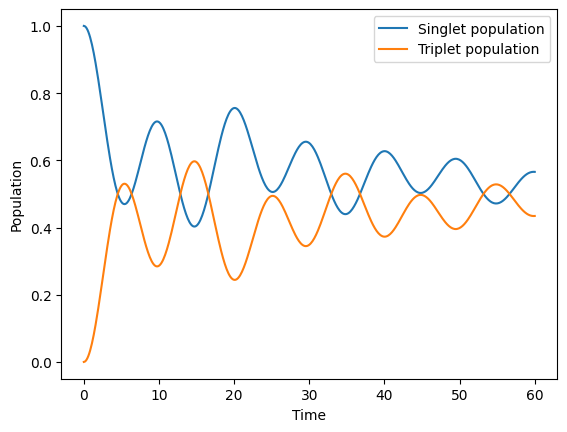

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# --- PARAMETERS ---
mu_B = 12.0       # Bohr magneton (arb. units)
B = 10.0          # Magnetic field magnitude (along z)
g1, g2 = 2, 2  # Electron g-factors
J = 0.05         # Exchange coupling constant
A1 = [0.1, 0.1, 0.2]  # Hyperfine for nucleus 1
A2 = [0.5, 0.5, 0.1]  # Hyperfine for nucleus 2
k_S = 0.1        # Singlet recombination rate
omega_drive = 3.3
# --- DEFINE SPIN OPERATORS ---
# Hilbert space order: electron1, electron2, nucleus1, nucleus2

sx_e1 = tensor(sigmax(), qeye(2), qeye(2), qeye(2))
sy_e1 = tensor(sigmay(), qeye(2), qeye(2), qeye(2))
sz_e1 = tensor(sigmaz(), qeye(2), qeye(2), qeye(2))

sx_e2 = tensor(qeye(2), sigmax(), qeye(2), qeye(2))
sy_e2 = tensor(qeye(2), sigmay(), qeye(2), qeye(2))
sz_e2 = tensor(qeye(2), sigmaz(), qeye(2), qeye(2))

sx_n1 = tensor(qeye(2), qeye(2), sigmax(), qeye(2))
sy_n1 = tensor(qeye(2), qeye(2), sigmay(), qeye(2))
sz_n1 = tensor(qeye(2), qeye(2), sigmaz(), qeye(2))

sx_n2 = tensor(qeye(2), qeye(2), qeye(2), sigmax())
sy_n2 = tensor(qeye(2), qeye(2), qeye(2), sigmay())
sz_n2 = tensor(qeye(2), qeye(2), qeye(2), sigmaz())

# --- HAMILTONIAN ---

B_vec = np.array([0, 0, B])  # magnetic field along z

H_Z = mu_B * (
    g1 * (B_vec[0]*sx_e1 + B_vec[1]*sy_e1 + B_vec[2]*sz_e1) +
    g2 * (B_vec[0]*sx_e2 + B_vec[1]*sy_e2 + B_vec[2]*sz_e2)
)

H_HF = (
    A1[0] * sx_e1 * sx_n1 + A1[1] * sy_e1 * sy_n1 + A1[2] * sz_e1 * sz_n1 +
    A2[0] * sx_e2 * sx_n2 + A2[1] * sy_e2 * sy_n2 + A2[2] * sz_e2 * sz_n2
)

H_J = J * (sx_e1 * sx_e2 + sy_e1 * sy_e2 + sz_e1 * sz_e2)

H = [H_Z + H_HF + H_J,
     [mu_B * (sx_e1 + sx_e2), 'cos(w*t)']]

args = {'w': omega_drive}


# --- INITIAL STATE ---

# Electron singlet state |S> = (|01> - |10>)/sqrt(2)
singlet_elec = (tensor(basis(2,0), basis(2,1)) - tensor(basis(2,1), basis(2,0))).unit()

# Nuclear spins in mixed state (identity / 4)
rho_nuc = tensor(qeye(2)/2, qeye(2)/2)

# Full initial state: singlet electrons tensor nuclear mixed state
rho0 = tensor(ket2dm(singlet_elec), rho_nuc)

# --- COLLAPSE OPERATORS ---

# Singlet projector on electron spins
P_S_elec = ket2dm(singlet_elec)

# Lift singlet projector to full space by tensor nuclear identity
P_S_full = tensor(P_S_elec, qeye(2), qeye(2))

# Collapse operator for singlet recombination
c_ops = [np.sqrt(k_S) * P_S_full]

# --- OBSERVABLES ---

# Triplet projector = Identity on electrons - singlet projector
P_T_elec = tensor(qeye(2), qeye(2)) - P_S_elec
P_T_full = tensor(P_T_elec, qeye(2), qeye(2))

observables = [P_S_full, P_T_full]

# --- TIME EVOLUTION ---

tlist = np.linspace(0, 60, 500)
result = mesolve(H, rho0, tlist,               , observables, args=args)
#result = mesolve(H, rho0, tlist, c_ops,observables)

# --- PLOTTING ---

plt.plot(tlist, result.expect[0], label='Singlet population')
plt.plot(tlist, result.expect[1], label='Triplet population')
plt.xlabel('Time')
plt.ylabel('Population')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


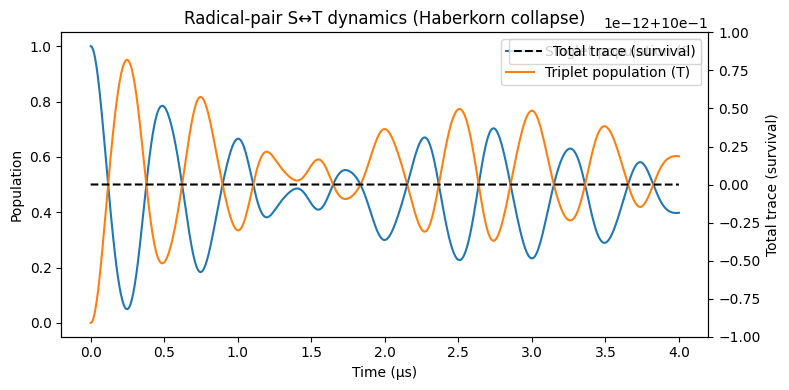

/usr/local/lib/python3.12/dist-packages/qutip/solver/solver_base.py:486: FutureWarning: "progress_bar" is now included in options:
 Use `options={"progress_bar": False / True / "tqdm" / "enhanced"}`
  warnings.warn(


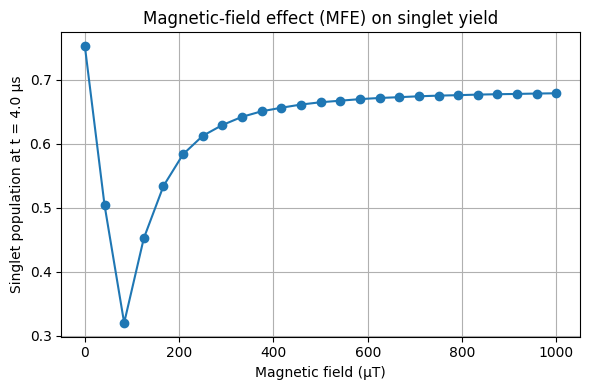

In [ ]:
#!/usr/bin/env python3
"""
Radical-pair singlet-triplet dynamics (Haberkorn master-equation style)
- Two electron spins + two nuclear spins (1/2 each)
- Zeeman (electrons), isotropic hyperfine (A-vectors), optional small exchange J
- Singlet-selective recombination via collapse operator sqrt(k_S)*P_S
- Units: angular frequency (rad/s) with ħ = 1 (so time in seconds)
"""
!pip install numpy matplotlib qutip

import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# -------------------- Physical constants --------------------
mu_B = 9.2740100783e-24   # J/T
h = 6.62607015e-34        # J*s
hbar = 1.054571817e-34    # J*s

# -------------------- Parameters (realistic radical-pair regime) --------------------
# Magnetic field (Earth-like)
B = 50e-6                # Tesla (50 µT ~ Earth field)
g_e = 2.0023             # electron g-factor (approx)

# Hyperfine couplings (MHz) for two nuclei (example values you can change)
A1_MHz = np.array([0.5, 0.0, 0.0])   # nucleus 1
A2_MHz = np.array([0.0, 0.0, 1.0])   # nucleus 2
MHz_to_rad = 2 * np.pi * 1e6
A1 = A1_MHz * MHz_to_rad   # convert to rad/s
A2 = A2_MHz * MHz_to_rad

# Exchange coupling J (MHz -> rad/s) (set tiny for RP weak-coupling)
J_MHz = 0.001   # 1 kHz
J = J_MHz * MHz_to_rad

# Recombination rates (s^-1)
k_S = 1e6     # singlet recombination (1e6 s^-1 => lifetime ~1 µs)
k_T = 0.0     # triplet recombination (set zero to emphasize singlet-selective)

# -------------------- Define operators for 4-spin Hilbert space: e1, e2, n1, n2 --------------------
sx_e1 = tensor(sigmax(), qeye(2), qeye(2), qeye(2))
sy_e1 = tensor(sigmay(), qeye(2), qeye(2), qeye(2))
sz_e1 = tensor(sigmaz(), qeye(2), qeye(2), qeye(2))

sx_e2 = tensor(qeye(2), sigmax(), qeye(2), qeye(2))
sy_e2 = tensor(qeye(2), sigmay(), qeye(2), qeye(2))
sz_e2 = tensor(qeye(2), sigmaz(), qeye(2), qeye(2))

sx_n1 = tensor(qeye(2), qeye(2), sigmax(), qeye(2))
sy_n1 = tensor(qeye(2), qeye(2), sigmay(), qeye(2))
sz_n1 = tensor(qeye(2), qeye(2), sigmaz(), qeye(2))

sx_n2 = tensor(qeye(2), qeye(2), qeye(2), sigmax())
sy_n2 = tensor(qeye(2), qeye(2), qeye(2), sigmay())
sz_n2 = tensor(qeye(2), qeye(2), qeye(2), sigmaz())

# -------------------- Hamiltonian (rad/s; use ħ=1) --------------------
omega_e = (g_e * mu_B * B) / hbar  # electron Zeeman angular frequency (rad/s)
H_Z = omega_e * (sz_e1 + sz_e2)

H_HF = (A1[0]*sx_e1*sx_n1 + A1[1]*sy_e1*sy_n1 + A1[2]*sz_e1*sz_n1
       + A2[0]*sx_e2*sx_n2 + A2[1]*sy_e2*sy_n2 + A2[2]*sz_e2*sz_n2)

H_J = J * (sx_e1*sx_e2 + sy_e1*sy_e2 + sz_e1*sz_e2)

H = H_Z + H_HF + H_J

# -------------------- Initial state --------------------
singlet_elec = (tensor(basis(2,0), basis(2,1)) - tensor(basis(2,1), basis(2,0))).unit()
rho_nuc = tensor(qeye(2)/2, qeye(2)/2)
rho0 = tensor(ket2dm(singlet_elec), rho_nuc)

# -------------------- Collapse operators (Haberkorn form) --------------------
P_S_elec = ket2dm(singlet_elec)
P_S_full = tensor(P_S_elec, qeye(2), qeye(2))
c_ops = []
if k_S > 0:
    c_ops.append(np.sqrt(k_S) * P_S_full)
if k_T > 0:
    P_T_elec = tensor(qeye(2), qeye(2)) - P_S_elec
    P_T_full = tensor(P_T_elec, qeye(2), qeye(2))
    c_ops.append(np.sqrt(k_T) * P_T_full)

# -------------------- Observables --------------------
P_T_elec = tensor(qeye(2), qeye(2)) - P_S_elec
P_T_full = tensor(P_T_elec, qeye(2), qeye(2))
observables = [P_S_full, P_T_full]

# -------------------- Time evolution --------------------
t_max = 4e-6  # simulate 4 µs
tlist = np.linspace(0, t_max, 800)

result = mesolve(H, rho0, tlist, c_ops, observables)

# Plot singlet & triplet populations vs time
plt.figure(figsize=(8,4))
plt.plot(tlist*1e6, result.expect[0], label='Singlet population (S)')
plt.plot(tlist*1e6, result.expect[1], label='Triplet population (T)')
plt.xlabel('Time (µs)')
plt.ylabel('Population')
plt.title('Radical-pair S↔T dynamics (Haberkorn collapse)')
plt.legend()

# compute and plot total survival (trace) by evolving states stored
res_states = mesolve(H, rho0, tlist, c_ops, [], options=Options(store_states=True))
traces = np.array([st.tr() for st in res_states.states])
ax2 = plt.twinx()
ax2.plot(tlist*1e6, traces, 'k--', label='Total trace (survival)')
ax2.set_ylabel('Total trace (survival)')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

# -------------------- Magnetic-Field Effect (MFE) sweep --------------------
Bs = np.linspace(0, 1e-3, 25)  # 0 - 1 mT
yields = []
for Bval in Bs:
    omega_e_val = (g_e * mu_B * Bval) / hbar
    H_Z_val = omega_e_val * (sz_e1 + sz_e2)
    H_val = H_Z_val + H_HF + H_J
    res = mesolve(H_val, rho0, tlist, c_ops, [], progress_bar=False)
    rho_final = res.states[-1]
    yields.append(expect(P_S_full, rho_final))

plt.figure(figsize=(6,4))
plt.plot(Bs*1e6, yields, '-o')
plt.xlabel('Magnetic field (µT)')
plt.ylabel('Singlet population at t = {:.1f} µs'.format(t_max*1e6))
plt.title('Magnetic-field effect (MFE) on singlet yield')
plt.grid(True)
plt.tight_layout()
plt.show()


ω_e = 8804213.274258254 rad/s
A1_z = 0.0 rad/s
J = -8771326.688822702 rad/s


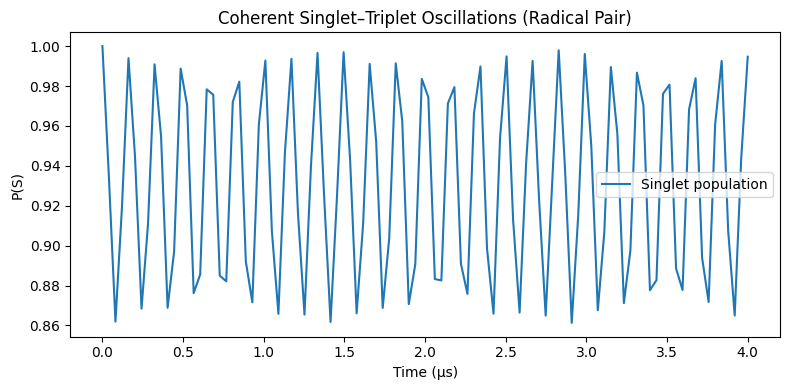

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# ---------- Constants ----------
mu_B = 9.2740100783e-24   # J/T
hbar = 1.054571817e-34    # J*s
g_e = 2.0023

# ---------- Parameters ----------
B = 50e-6                # Tesla (Earth-like)
A1_MHz = np.array([0.5, 0.0, 0.0])   # hyperfine coupling for nucleus 1
A2_MHz = np.array([0.0, 0.0, 1.0])   # hyperfine coupling for nucleus 2
MHz_to_rad = 2*np.pi*1e6
A1 = A1_MHz * MHz_to_rad
A2 = A2_MHz * MHz_to_rad
J_MHz = -1.396
J = J_MHz * MHz_to_rad

# ---------- Spin operators (Hilbert space: e1, e2, n1, n2) ----------
sx_e1 = tensor(sigmax(), qeye(2), qeye(2), qeye(2))
sy_e1 = tensor(sigmay(), qeye(2), qeye(2), qeye(2))
sz_e1 = tensor(sigmaz(), qeye(2), qeye(2), qeye(2))

sx_e2 = tensor(qeye(2), sigmax(), qeye(2), qeye(2))
sy_e2 = tensor(qeye(2), sigmay(), qeye(2), qeye(2))
sz_e2 = tensor(qeye(2), sigmaz(), qeye(2), qeye(2))

sx_n1 = tensor(qeye(2), qeye(2), sigmax(), qeye(2))
sy_n1 = tensor(qeye(2), qeye(2), sigmay(), qeye(2))
sz_n1 = tensor(qeye(2), qeye(2), sigmaz(), qeye(2))

sx_n2 = tensor(qeye(2), qeye(2), qeye(2), sigmax())
sy_n2 = tensor(qeye(2), qeye(2), qeye(2), sigmay())
sz_n2 = tensor(qeye(2), qeye(2), qeye(2), sigmaz())

# ---------- Hamiltonian ----------
omega_e = (g_e * mu_B * B) / hbar   # Zeeman frequency (rad/s)
H_Z = omega_e * (sz_e1 + sz_e2)
H_HF = (A1[0]*sx_e1*sx_n1 + A1[1]*sy_e1*sy_n1 + A1[2]*sz_e1*sz_n1
       + A2[0]*sx_e2*sx_n2 + A2[1]*sy_e2*sy_n2 + A2[2]*sz_e2*sz_n2)
H_J = J * (sx_e1*sx_e2 + sy_e1*sy_e2 + sz_e1*sz_e2)
H = H_Z + H_HF + H_J


# ---------- Initial state (pure singlet × random nuclear) ----------
singlet_elec = (tensor(basis(2,0), basis(2,1)) - tensor(basis(2,1), basis(2,0))).unit()
psi_nuc = tensor(basis(2,0), basis(2,1))  # example nuclear state
psi0 = tensor(singlet_elec, psi_nuc)

# ---------- Define singlet projector ----------
P_S_elec = ket2dm(singlet_elec)
P_S_full = tensor(P_S_elec, qeye(2), qeye(2))

# ---------- Time evolution ----------
tlist = np.linspace(0, 4e-6, 100)  # 0–4 µs

result = sesolve(H, psi0, tlist, [P_S_full],
                 options = Options(nsteps=10000, atol=1e-8, rtol=1e-6))

print("ω_e =", omega_e, "rad/s")
print("A1_z =", A1[2], "rad/s")
print("J =", J, "rad/s")

# ---------- Plot ----------
plt.figure(figsize=(8,4))
plt.plot(tlist*1e6, result.expect[0], label='Singlet population')
plt.xlabel('Time (µs)')
plt.ylabel('P(S)')
plt.title('Coherent Singlet–Triplet Oscillations (Radical Pair)')
plt.legend()
plt.tight_layout()
plt.show()



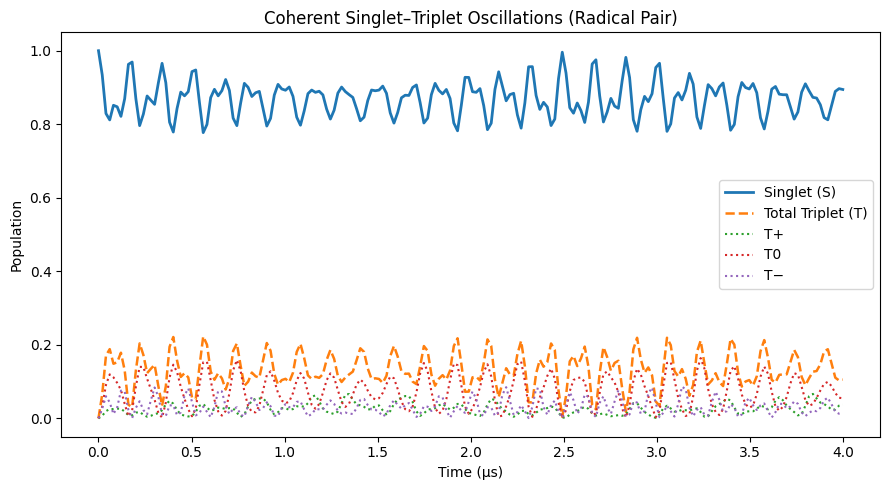

ω_e = 8.804e+06 rad/s
J = -8.771e+06 rad/s
A1_z = 3.142e+06 rad/s


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# ---------- Constants ----------
mu_B = 9.2740100783e-24   # J/T
hbar = 1.054571817e-34    # J*s
g_e = 2.0023

# ---------- Parameters ----------
B = 50e-6  # Tesla (Earth-like field)
A1_MHz = np.array([0.5, 0.5, 0.5])   # hyperfine coupling for nucleus 1 (MHz)
A2_MHz = np.array([1.0, 1.0, 1.0])   # hyperfine coupling for nucleus 2 (MHz)
MHz_to_rad = 2 * np.pi * 1e6
A1 = A1_MHz * MHz_to_rad
A2 = A2_MHz * MHz_to_rad
J_MHz = -1.396                    # MHz exchange coupling
J = J_MHz * MHz_to_rad

# ---------- Spin operators (Hilbert space: e1, e2, n1, n2) ----------
sx_e1 = tensor(sigmax(), qeye(2), qeye(2), qeye(2))
sy_e1 = tensor(sigmay(), qeye(2), qeye(2), qeye(2))
sz_e1 = tensor(sigmaz(), qeye(2), qeye(2), qeye(2))

sx_e2 = tensor(qeye(2), sigmax(), qeye(2), qeye(2))
sy_e2 = tensor(qeye(2), sigmay(), qeye(2), qeye(2))
sz_e2 = tensor(qeye(2), sigmaz(), qeye(2), qeye(2))

sx_n1 = tensor(qeye(2), qeye(2), sigmax(), qeye(2))
sy_n1 = tensor(qeye(2), qeye(2), sigmay(), qeye(2))
sz_n1 = tensor(qeye(2), qeye(2), sigmaz(), qeye(2))

sx_n2 = tensor(qeye(2), qeye(2), qeye(2), sigmax())
sy_n2 = tensor(qeye(2), qeye(2), qeye(2), sigmay())
sz_n2 = tensor(qeye(2), qeye(2), qeye(2), sigmaz())

# ---------- Hamiltonian ----------
omega_e = (g_e * mu_B * B) / hbar   # Zeeman frequency (rad/s)
H_Z = omega_e * (sz_e1 + sz_e2)
H_HF = (A1[0]*sx_e1*sx_n1 + A1[1]*sy_e1*sy_n1 + A1[2]*sz_e1*sz_n1
       + A2[0]*sx_e2*sx_n2 + A2[1]*sy_e2*sy_n2 + A2[2]*sz_e2*sz_n2)
H_J = J * (sx_e1*sx_e2 + sy_e1*sy_e2 + sz_e1*sz_e2)
H = H_Z + H_HF + H_J

# ---------- Initial state (singlet × nuclear state) ----------
singlet_elec = (tensor(basis(2,0), basis(2,1)) - tensor(basis(2,1), basis(2,0))).unit()
psi_nuc = tensor(basis(2,0), basis(2,1))  # example nuclear state
psi0 = tensor(singlet_elec, psi_nuc)


# ---------- Define projectors ----------
# Singlet
P_S_elec = ket2dm(singlet_elec)
P_S_full = tensor(P_S_elec, qeye(2), qeye(2))

# Total triplet = identity (2⊗2) - singlet
P_T_elec = tensor(qeye(2), qeye(2)) - P_S_elec
P_T_full = tensor(P_T_elec, qeye(2), qeye(2))

# Individual triplet sublevels (optional)
T_plus  = tensor(basis(2,0), basis(2,0))
T_minus = tensor(basis(2,1), basis(2,1))
T_zero  = (tensor(basis(2,0), basis(2,1)) + tensor(basis(2,1), basis(2,0))).unit()

P_Tp_full = tensor(ket2dm(T_plus), qeye(2), qeye(2))
P_T0_full = tensor(ket2dm(T_zero), qeye(2), qeye(2))
P_Tm_full = tensor(ket2dm(T_minus), qeye(2), qeye(2))

# ---------- Time evolution ----------
tlist = np.linspace(0, 4e-6, 200)  # 0–4 µs

options = Options(nsteps=10000, atol=1e-8, rtol=1e-6)

# Solve for all projectors
result = sesolve(H, psi0, tlist, [P_S_full, P_T_full, P_Tp_full, P_T0_full, P_Tm_full], options=options)

# ---------- Plot ----------
plt.figure(figsize=(9,5))
plt.plot(tlist*1e6, result.expect[0], label='Singlet (S)', lw=2)
plt.plot(tlist*1e6, result.expect[1], '--', label='Total Triplet (T)', lw=1.8)
plt.plot(tlist*1e6, result.expect[2], ':', label='T+', lw=1.5)
plt.plot(tlist*1e6, result.expect[3], ':', label='T0', lw=1.5)
plt.plot(tlist*1e6, result.expect[4], ':', label='T−', lw=1.5)
plt.xlabel('Time (µs)')
plt.ylabel('Population')
plt.title('Coherent Singlet–Triplet Oscillations (Radical Pair)')
plt.legend()
plt.tight_layout()
plt.show()

# ---------- Print key frequencies ----------
print(f"ω_e = {omega_e:.3e} rad/s")
print(f"J = {J:.3e} rad/s")
print(f"A1_z = {A1[2]:.3e} rad/s")
